In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:\\Users\\deept\\Downloads\\netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df["director"] = df["director"].fillna("Unknown")

In [9]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            825
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [10]:
df["country"] = df["country"].fillna("Unknown")

In [11]:
df["cast"] = df["cast"].fillna("Unknown")

In [12]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [13]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [14]:
df["duration"] = df["duration"].fillna("Unknown")

In [15]:
df["date_added"] = df["date_added"].fillna("Unknown")

In [16]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
import numpy as np
Data=df.select_dtypes(include=np.number)

In [19]:
for i in Data:
    q1=Data[i].quantile(0.25)
    q2=Data[i].quantile(0.50)
    q3=Data[i].quantile(0.75)

In [20]:
IQR=q3-q1
UW=q3+1.5*IQR
LW=q1-1.5*IQR
Outlier=((Data[i]>UW)|(Data[i]<LW))
Outlier.sum()

np.int64(719)

In [21]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [22]:
Data.loc[(Data[i]>UW) | (Data[i]<LW),i] = q2

In [23]:
Outlier.sum()

np.int64(719)

Data Analysis

In [24]:
country_count = df['country'].value_counts().head(10)
print(country_count)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [25]:
genre_count = df['listed_in'].value_counts().head(10)
print(genre_count)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


In [26]:
rating_count = df['rating'].value_counts()
print(rating_count)

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [27]:
release_count = df['release_year'].value_counts().sort_index
print(release_count)

<bound method Series.sort_index of release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: count, Length: 74, dtype: int64>


In [47]:
Indian_tvshow = df[(df['country'].str.contains("India")) & (df['type'].str.lower()=='tv show')]
print(len(Indian_tvshow))
Indian_movies = df[(df['country'].str.contains("India")) & (df['type'].str.lower()=='movie')]
print(len(Indian_movies))

84
962


In [28]:
df['duration_min'] = df['duration'].str.extract('(\d+)').astype(float)

In [29]:
avg_duration = df.groupby('release_year')['duration_min'].mean()
print(avg_duration)

release_year
1925     1.000000
1942    35.000000
1943    62.666667
1944    52.000000
1945    38.750000
          ...    
2017    71.439379
2018    64.877071
2019    58.161165
2020    50.769150
2021    46.040541
Name: duration_min, Length: 74, dtype: float64


# Data Visualization

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

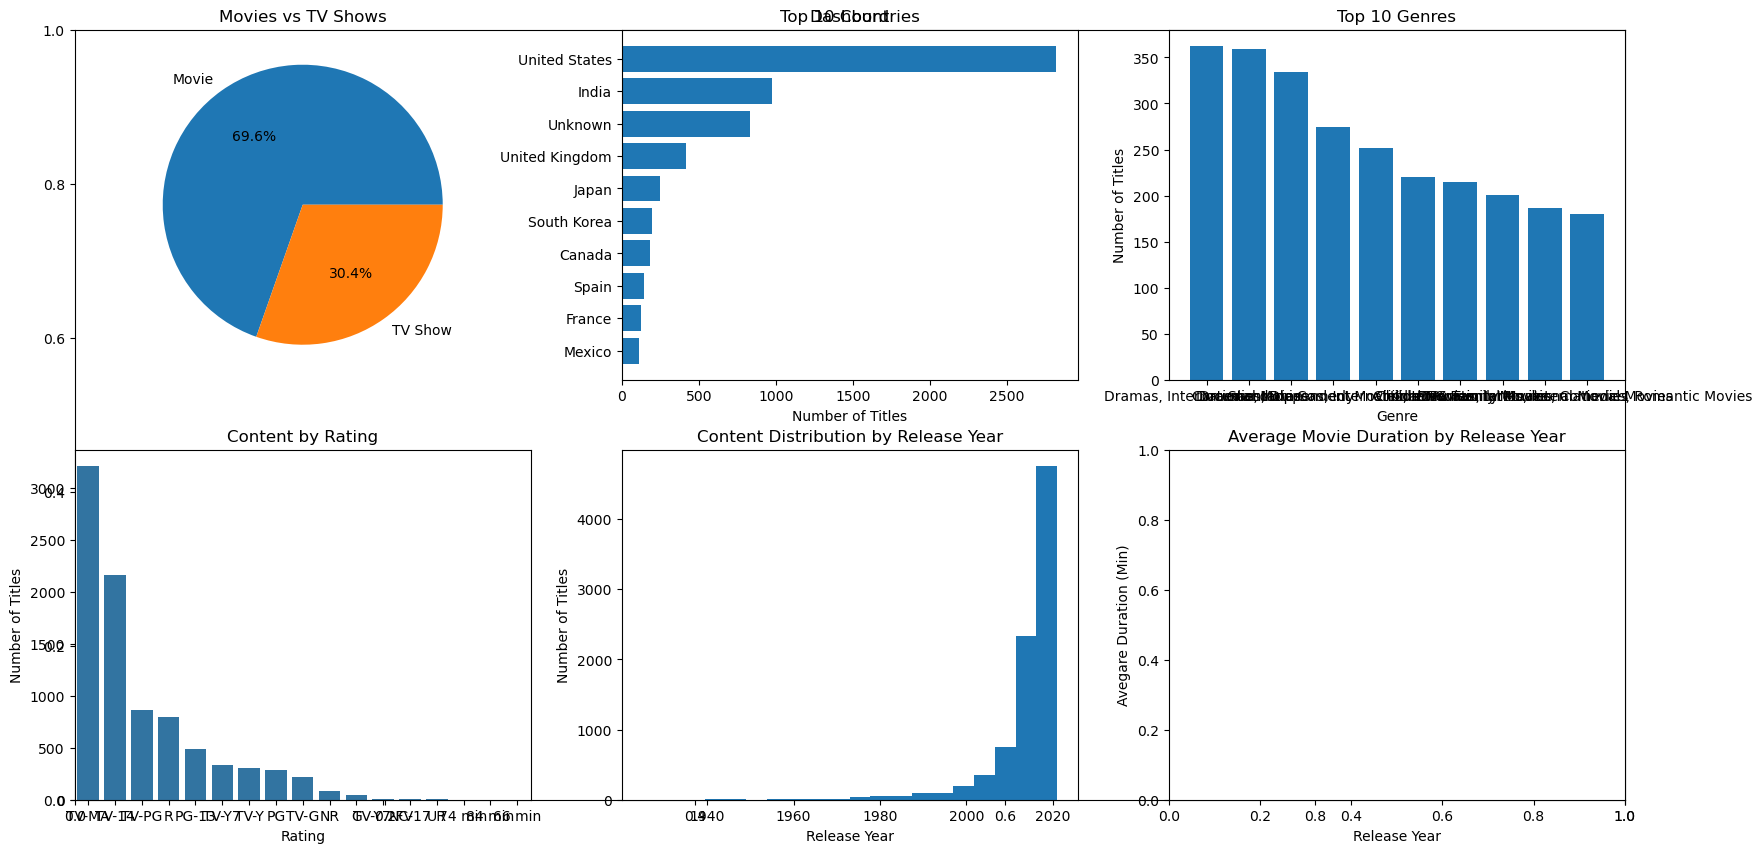

In [31]:
plt.figure(figsize=(20,10))
plt.title("Dashbord")
plt.subplot(2,3,1)
type_count = df['type'].value_counts()
plt.pie(type_count.values, labels = type_count.index, autopct = '%1.1f%%')
plt.title("Movies vs TV Shows")

plt.subplot(2,3,2)
plt.barh(country_count.index[::-1], country_count.values[::-1])
plt.title("Top 10 Countries")
plt.xlabel("Number of Titles")

plt.subplot(2,3,3)
plt.bar(genre_count.index, genre_count.values)
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.subplot(2,3,4)
sns.countplot(x="rating", data=df, order=df['rating'].value_counts().index)
plt.title("Content by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.subplot(2,3,5)
plt.hist(df['release_year'],bins=20)
plt.title("Content Distribution by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.subplot(2,3,6)
plt.title("Average Movie Duration by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Avegare Duration (Min)")

plt.show()

In [32]:
type_count = df['type'].value_counts().reset_index()
type_count.columns = ['Type','Count']
type_count.to_csv('netflix_type.csv',index=False)

country_df = df['country'].dropna().str.split(', ').explode()
country_count = country_df.value_counts().head(10).reset_index()
country_count.columns = ['Country','Count']
country_count.to_csv('netflix_countries.csv',index = False)

genre_df = df['listed_in'].dropna().str.split(', ').explode()
genre_count = genre_df.value_counts().head(10).reset_index()
genre_count.columns = ['Genre','Count']
genre_count.to_csv('netflix_genre.csv',index = False)

rating_count = df['rating'].value_counts().reset_index()
rating_count.columns = ['Rating','Count']
rating_count.to_csv('netflix_rating.csv',index = False)

release_count = df['release_year'].value_counts().sort_index().reset_index()
release_count.columns = ['Release_Year','Count']
release_count.to_csv('netflix_release_year.csv',index = False)

df['duration_min'] = df['duration'].str.extract('(\d+)').astype(float)
average_duration = df.groupby('release_year')['duration_min'].mean().reset_index()
average_duration.columns = ['Release_Year','Average_Duration']
average_duration.to_csv('netflix_average_duration.csv',index = False)

print("All csv files created successfully!")

All csv files created successfully!


In [33]:
import os

print(os.getcwd())

C:\Users\deept


In [34]:
os.listdir()

['.anaconda',
 '.android',
 '.arduinoIDE',
 '.cache',
 '.conda',
 '.config',
 '.continuum',
 '.copilot',
 '.docker',
 '.dotnet',
 '.eclipse',
 '.emulator_console_auth_token',
 '.git',
 '.gitconfig',
 '.gradle',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.junie',
 '.jupyter',
 '.lemminx',
 '.lesshst',
 '.m2',
 '.matplotlib',
 '.node_repl_history',
 '.p2',
 '.templateengine',
 '.vscode',
 '.vscode-shared',
 'AI WEBSCRAPER.py',
 'AndroidStudioProjects',
 'AppData',
 'Application Data',
 'clas.py',
 'Contacts',
 'Cookies',
 'Customer_Shopping_Behavior.ipynb',
 'Data Science.ipynb',
 'Desktop',
 'Documents',
 'Downloads',
 'dsa projects',
 'eclipse',
 'eclipse-workspace',
 'Favorites',
 'firstimport.py',
 'from rectangle import Rectangle.py',
 'git',
 'import cv2.py',
 'IntelGraphicsProfiles',
 'Job_Market.ipynb',
 'Job_Mart.ipynb',
 'Links',
 'Local Settings',
 'Machine Learning.ipynb',
 'Music',
 'My Documents',
 'mymoviedb.csv',
 'Netflix Movie Analysis.ipynb',
 'netflix_average_d